In [112]:
import pandas as pd
import numpy as np
#visualization
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
#machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix


In [113]:

weather_df=pd.read_csv("../data/weatherAUS.csv")



In [114]:
weather_df.sample(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
17240,2015-02-01,Newcastle,19.2,26.0,0.7,NaN,NaN,NaN,NaN,NaN,...,80.0,65.0,NaN,NaN,6.0,6.0,22.8,25.5,No,Yes
15857,2011-01-21,Newcastle,18.7,29.5,0.2,NaN,NaN,NaN,NaN,NE,...,65.0,52.0,NaN,NaN,1.0,1.0,24.4,28.5,No,No
84766,2010-07-30,Brisbane,15.3,26.4,0.0,0.2,8.0,NE,20.0,SW,...,95.0,61.0,1021.1,1017.5,8.0,1.0,17.5,24.3,No,No
71572,2012-04-24,Mildura,6.4,17.0,0.8,3.8,6.2,SW,48.0,WSW,...,85.0,51.0,1019.0,1018.5,7.0,7.0,10.6,15.8,No,No
24267,2009-04-19,Penrith,15.2,19.9,0.0,NaN,NaN,SSE,46.0,SSW,...,63.0,98.0,NaN,NaN,NaN,NaN,19.0,16.6,No,Yes


In [115]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [116]:
weather_df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


In [117]:
weather_df.shape

(145460, 23)

In [118]:
weather_df.isnull().sum()

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64

In [119]:
#calculate the percentage of missing values
missing_percentage=(weather_df.isnull().sum()/len(weather_df))*100
missing_df=pd.DataFrame({
    'Missing values':weather_df.isnull().sum(),
    'Percentage':missing_percentage
})
missing_df.sort_values(by='Percentage',ascending=False)

,Missing values,Percentage
Sunshine,69835,48.009762
Evaporation,62790,43.166506
Cloud3pm,59358,40.807095
Cloud9am,55888,38.421559
Pressure9am,15065,10.356799
Pressure3pm,15028,10.331363
WindDir9am,10566,7.263853
WindGustDir,10326,7.098859
WindGustSpeed,10263,7.055548
Humidity3pm,4507,3.098446


In [120]:
weather_df.drop(
    columns=["Sunshine","Evaporation","Cloud9am","Cloud3pm"],inplace=True
)

In [121]:
#removing rows with missing targets
weather_df=weather_df.dropna(subset="RainTomorrow")

In [122]:
#filling the remaining  numerical null values with the median
numerical_cols=['MaxTemp','MinTemp','WindSpeed9am','Temp9am','Humidity9am','WindSpeed3pm','Rainfall','Temp3pm',
               'Humidity3pm','WindGustSpeed','Pressure3pm','Pressure9am']
for col in numerical_cols:
    weather_df[col]=weather_df[col].fillna(weather_df[col].median())

In [123]:
#fill the remaining categorical columns with the mode
categorical_cols=['RainToday','WindGustDir','WindDir9am','WindDir3pm']
for col in categorical_cols:
    weather_df[col]=weather_df[col].fillna(weather_df[col].mode()[0])

In [124]:
weather_df.isnull().sum()

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64

In [125]:
weather_df['RainToday'].value_counts()

RainToday
No     110738
Yes     31455
Name: count, dtype: int64

In [126]:
weather_df['RainTomorrow'].value_counts()

RainTomorrow
No     110316
Yes     31877
Name: count, dtype: int64

In [127]:
weather_df['RainToday']=weather_df['RainToday'].map({'No':0,"Yes":1})
weather_df['RainTomorrow']=weather_df['RainTomorrow'].map({'No':0,"Yes":1})

In [128]:
weather_df['RainToday'].unique()

array([0, 1], dtype=int64)

In [129]:
weather_df['Location']

0         Albury
1         Albury
2         Albury
3         Albury
4         Albury
           ...  
145454     Uluru
145455     Uluru
145456     Uluru
145457     Uluru
145458     Uluru
Name: Location, Length: 142193, dtype: object

In [130]:
weather_df=pd.get_dummies(
    weather_df,columns=['Location','WindGustDir','WindDir9am','WindDir3pm'],
    drop_first=True
)

In [131]:
weather_df.head()

,Date,MinTemp,MaxTemp,Rainfall,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,...,WindDir3pm_NNW,WindDir3pm_NW,WindDir3pm_S,WindDir3pm_SE,WindDir3pm_SSE,WindDir3pm_SSW,WindDir3pm_SW,WindDir3pm_W,WindDir3pm_WNW,WindDir3pm_WSW
0,2008-12-01,13.4,22.9,0.6,44.0,20.0,24.0,71.0,22.0,1007.7,...,False,False,False,False,False,False,False,False,True,False
1,2008-12-02,7.4,25.1,0.0,44.0,4.0,22.0,44.0,25.0,1010.6,...,False,False,False,False,False,False,False,False,False,True
2,2008-12-03,12.9,25.7,0.0,46.0,19.0,26.0,38.0,30.0,1007.6,...,False,False,False,False,False,False,False,False,False,True
3,2008-12-04,9.2,28.0,0.0,24.0,11.0,9.0,45.0,16.0,1017.6,...,False,False,False,False,False,False,False,False,False,False
4,2008-12-05,17.5,32.3,1.0,41.0,7.0,20.0,82.0,33.0,1010.8,...,False,True,False,False,False,False,False,False,False,False


In [132]:
weather_df.drop("Date",axis=1,inplace=True)

In [133]:
#### Note:Feature scaling is not applied because Random Forest is a tree_based algorithm and is not sensitive to differences in feature scales.

In [134]:
##target
y=weather_df['RainTomorrow']
#features
X=weather_df.drop("RainTomorrow",axis=1)

In [135]:
X.shape

(142193, 106)

In [136]:
y.shape

(142193,)

In [137]:
#train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [138]:
print(X_train.shape)
print(X_test.shape)

(113754, 106)
(28439, 106)


### Training the model using Random Forest

In [139]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=50, n_jobs=-1, random_state=42)

In [140]:
accuracy=accuracy_score(y_test,y_pred)
print(f"Accuracy:{accuracy:.4f}")

Accuracy:0.8539


In [141]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22064
           1       0.78      0.49      0.60      6375

    accuracy                           0.85     28439
   macro avg       0.82      0.72      0.76     28439
weighted avg       0.85      0.85      0.84     28439



In [142]:
cm1=confusion_matrix(y_test,y_pred)
print(cm1)

[[21160   904]
 [ 3252  3123]]


### training using decision tree

In [143]:
from sklearn.tree import DecisionTreeClassifier

In [144]:
dt_model=DecisionTreeClassifier(
    random_state=42
)
dt_model.fit(X_train,y_train)
dt_predictions=dt_model.predict(X_test)

In [145]:
dt_accuracy=accuracy_score(y_test,dt_predictions)
print(f"The Decision tree accuracy is:{dt_accuracy:.4f}")

The Decision tree accuracy is:0.7892


### Training using gradient boosting

In [146]:
from sklearn.ensemble import GradientBoostingClassifier

In [147]:
gb_model=GradientBoostingClassifier(
    random_state=42
)
gb_model.fit(X_train,y_train)
gb_predictions=gb_model.predict(X_test)
gb_accuracy=accuracy_score(y_test,gb_predictions)
print(f"The accuracy of Gradient Boosting algorithm is:{gb_accuracy}")

The accuracy of Gradient Boosting algorithm is:0.8495727697879673


### Comparing all models

In [148]:
comparison=pd.DataFrame({
    "Model":['Decision Tree','Random Forest','Gradient Boosting'],
    "Accuracy":[dt_accuracy,accuracy,gb_accuracy]
})
comparison

,Model,Accuracy
0,Decision Tree,0.789233
1,Random Forest,0.853863
2,Gradient Boosting,0.849573


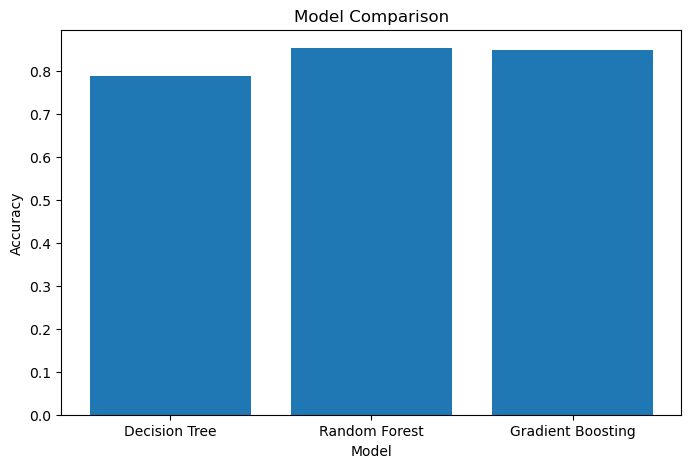

In [149]:
plt.figure(figsize=(8,5))
plt.bar(
    comparison['Model'],comparison['Accuracy']
)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.title("Model Comparison")
plt.show()

In [150]:
best_model=comparison.iloc[
comparison['Accuracy'].idxmax()
]
print(best_model)

Model       Random Forest
Accuracy         0.853863
Name: 1, dtype: object


### Feature importance - tells how much each feature contributes to a machine learning model's predictions

In [151]:
importance=pd.DataFrame({
    "Feature":X.columns,
    "Importance":rf_model.feature_importances_
})
importance=importance.sort_values(
    by="Importance",
    ascending=False
)
importance.head(15)

,Feature,Importance
7,Humidity3pm,0.264174
2,Rainfall,0.093924
6,Humidity9am,0.079793
9,Pressure3pm,0.065597
12,RainToday,0.065125
3,WindGustSpeed,0.060314
8,Pressure9am,0.060157
11,Temp3pm,0.050721
1,MaxTemp,0.039269
0,MinTemp,0.036992


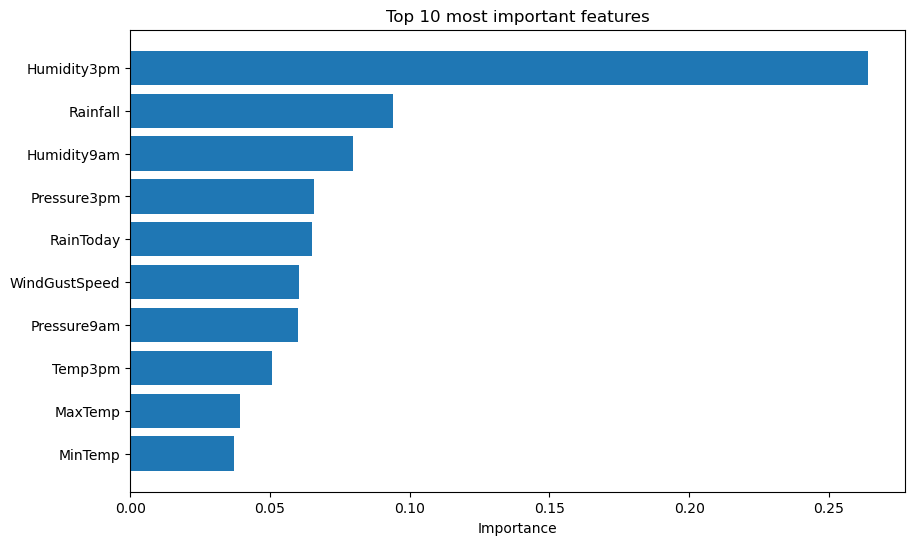

In [152]:
top_features=importance.head(10)
plt.figure(figsize=(10,6))
plt.barh(
    top_features['Feature'],
    top_features['Importance']
)
plt.xlabel("Importance")
plt.title("Top 10 most important features")
plt.gca().invert_yaxis()
plt.show()

In [153]:
import joblib
joblib.dump(
    rf_model,
    "../models/rainfall_prediction_model.pkl"
)

['../models/rainfall_prediction_model.pkl']